# XOR Neural Network Visualization

This notebook demonstrates training a neural network on the XOR problem and visualizing the decision boundary.

In [6]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from ml_core_numpy.losses import BinaryCrossentropy as BCE_Loss
from ml_core_numpy import Network as Neural_Network
from ml_core_numpy.layers import DenseLayer as Dense_Layer
from ml_core_numpy.activations import Sigmoid as Sigmoid_Activation
from ml_core_numpy.activations import ReLU as ReLU_Activation
from ml_core_numpy.activations import Tanh as Tanh_Activation

## XOR Dataset

The XOR (exclusive OR) problem is a classic non-linear classification problem that cannot be solved by a single-layer perceptron.

In [7]:
# Define XOR inputs and expected outputs
inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]
labels = [
    [0],
    [1],
    [1],
    [0]
]

# Convert labels to numpy array for calculations
labels = np.array(labels)

## Training the Neural Network

We'll create a neural network with:
- 2 input neurons (for the 2 XOR inputs)
- 4 neurons in the hidden layer
- 1 output neuron (for binary classification)

In [8]:
# Training parameters
num_epochs = 5000
learning_rate = 0.2

# Initialize the loss function
bce_loss = BCE_Loss()

# Initialize the network
# 2 inputs, 4 hidden, 1 output
neural_network = Neural_Network([
    Dense_Layer(input_size=2, output_size=4, initializer='xavier'),
    Tanh_Activation(),
    Dense_Layer(input_size=4, output_size=1, initializer='xavier'),
    Sigmoid_Activation(),
])

# Lists to track progress
loss_history = []
accuracy_history = []

for epoch in range(num_epochs):
    # Forward pass
    predictions = neural_network.forward(inputs=inputs)
    loss = bce_loss.forward(predictions=predictions, labels=labels)
    gradient = bce_loss.backward()
    
    # Backward pass
    neural_network.backward(loss_gradient=gradient, learning_rate=learning_rate)
    
    # Record loss every so often
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        loss_history.append(loss)
        predicted_labels = (predictions > 0.5).astype(int)
        accuracy = (predicted_labels == labels).sum() / len(labels)
        accuracy_history.append(accuracy)
        if epoch % 1000 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch}/{num_epochs}, Loss: {loss:.6f}, Accuracy: {accuracy * 100:.2f}%")

final_predictions = neural_network.forward(inputs=inputs)
final_preds_rounded = (final_predictions > 0.5).astype(int)
final_accuracy = (final_preds_rounded == labels).sum() / len(labels)

print(f"\nFinal XOR Accuracy: {final_accuracy * 100:.2f}% ✅")

Epoch 0/5000, Loss: 0.752285, Accuracy: 50.00%
Epoch 1000/5000, Loss: 0.557933, Accuracy: 100.00%
Epoch 2000/5000, Loss: 0.131854, Accuracy: 100.00%
Epoch 3000/5000, Loss: 0.048992, Accuracy: 100.00%
Epoch 4000/5000, Loss: 0.027926, Accuracy: 100.00%
Epoch 4999/5000, Loss: 0.019128, Accuracy: 100.00%

Final XOR Accuracy: 100.00% ✅


## Visualizing Training Progress

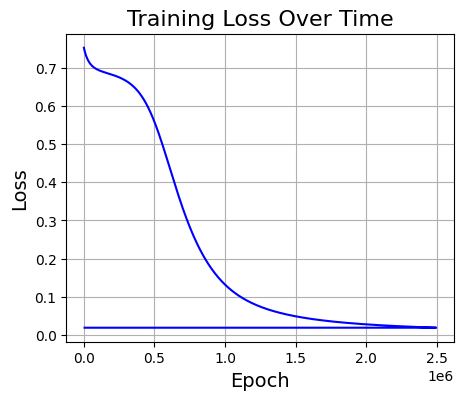

In [9]:
# Plot loss over time
plt.figure(figsize=(5, 4))
epochs_tracked = [i*num_epochs for i in range(len(loss_history)-1)] + [num_epochs-1]
plt.plot(epochs_tracked, loss_history, 'b-')
plt.title('Training Loss Over Time', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True)
plt.show()

## Decision Boundary Visualization

Input: [0, 0] | Actual: 0 | Predicted: 0.0158 | Rounded: 0.0
Input: [0, 1] | Actual: 1 | Predicted: 0.9794 | Rounded: 1.0
Input: [1, 0] | Actual: 1 | Predicted: 0.9794 | Rounded: 1.0
Input: [1, 1] | Actual: 0 | Predicted: 0.0187 | Rounded: 0.0


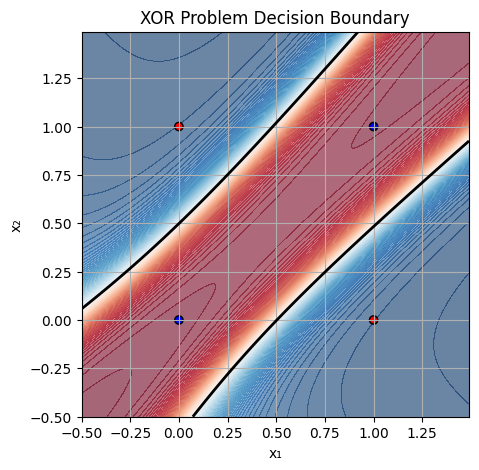

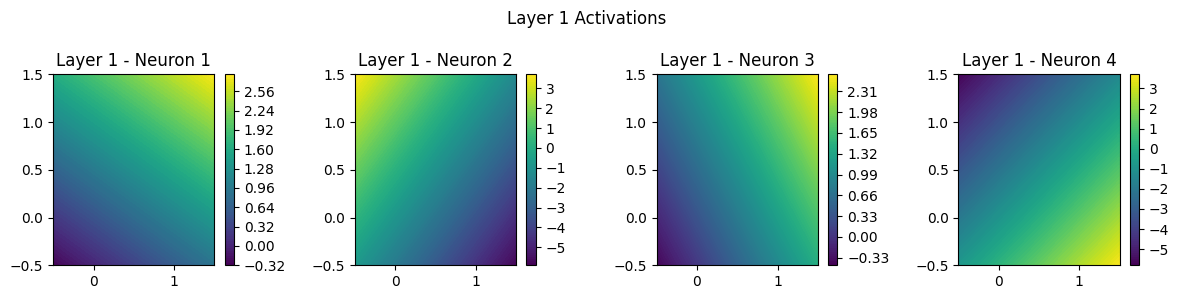

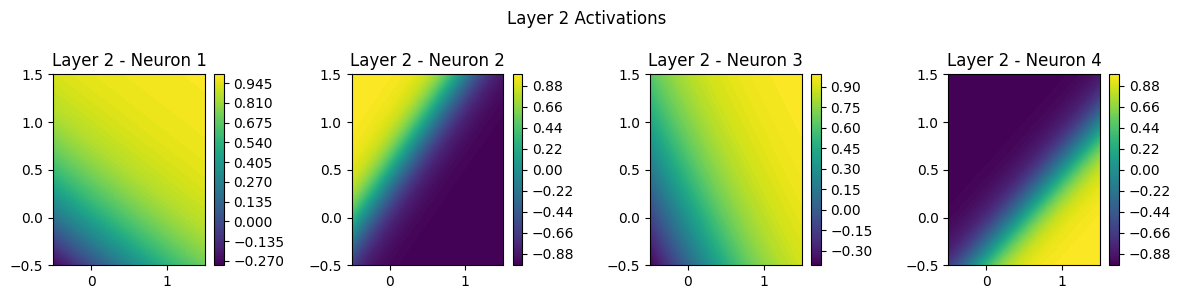

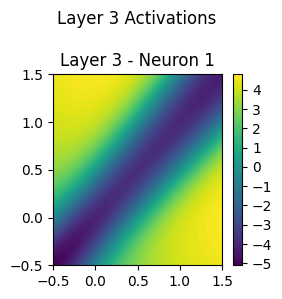

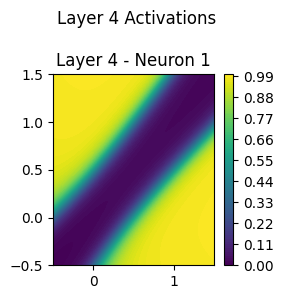

Layer 1 Neuron 1 weights: [ 0.59489156 -2.52599948  0.9220556   2.20229035]
Layer 1 Neuron 2 weights: [ 0.96486042  2.21078721  0.57071794 -2.49296325]


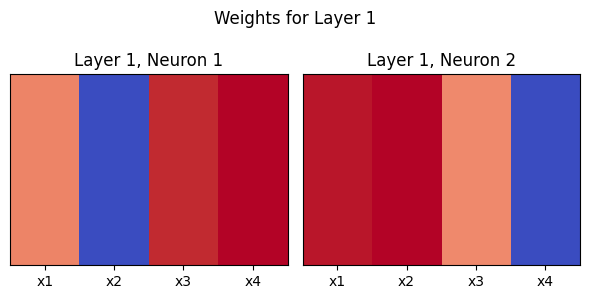

Layer 3 Neuron 1 weights: [1.31839501]
Layer 3 Neuron 2 weights: [5.28528289]
Layer 3 Neuron 3 weights: [1.06797289]
Layer 3 Neuron 4 weights: [5.29534156]


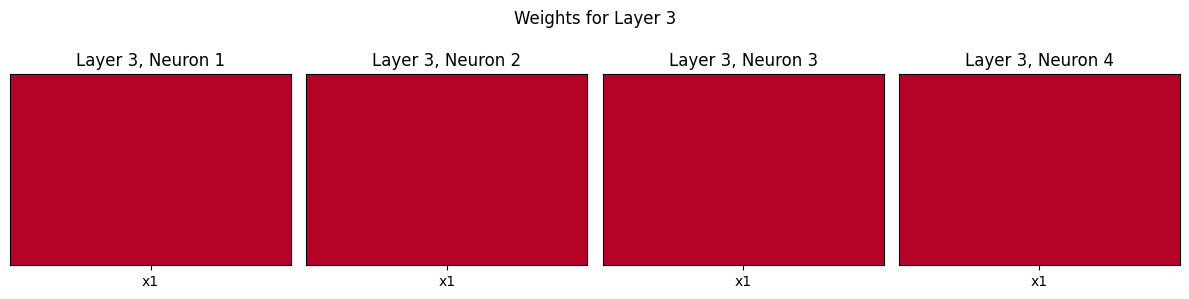

In [10]:
# Make predictions
final_predictions = neural_network.forward(inputs)
rounded_predictions = np.round(final_predictions)

# Display predictions vs actual
for i in range(len(inputs)):
    print(f"Input: {inputs[i]} | Actual: {labels[i][0]} | Predicted: {final_predictions[i][0]:.4f} | Rounded: {rounded_predictions[i][0]}")

# Visualize the decision boundary
from visualize import plot_decision_boundary
from visualize import plot_all_layer_activations
from visualize import plot_layer_weights

plot_decision_boundary(model=neural_network, X=inputs, y=labels, title="XOR Problem Decision Boundary")
plot_all_layer_activations(model=neural_network)
plot_layer_weights(neural_network)